In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras
import ast
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow import keras


In [2]:
# -------------------------
# CONFIGURAÇÕES GERAIS
# -------------------------
PREDICTORS = ["PwmD", "PwmE"]
TARGET = ["Wd", "We"]
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET) 
TIME_STEPS = 9
NDATASETS = 4  # ajuste se houver mais datasets

In [3]:
# -------------------------
# LEITURA DOS DATASETS
# -------------------------
Datasets = []
for i in range(NDATASETS):
    Dataset = pd.read_csv(f"../Dados/TestData/Data{i + 1}.csv")
    Dataset.index = (np.arange(0, len(Dataset)) * 0.07).round(5)
    Datasets.append(Dataset)
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head())

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.28   3.28  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.21  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.28  0.0  0.7    0.0  0.0  0.0   3.28   3.28  68.95  68.95
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.02   3.02  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.21  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.28  0.0  0.7    0.0  0.0  0.0   3.02   3.02  63.44  63.44
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   

In [4]:
# -------------------------
# NORMALIZAÇÃO
# -------------------------
NormDatasets = []
SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = pd.read_csv(f"../Dados/Data1.csv")
SCALER.fit(TrainDataset[PREDICTORS])
OUT_SCALER.fit(TrainDataset[TARGET])

for i in range(NDATASETS):
    CurrentTestDataset = Datasets[i].copy()

    CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
    CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])

    NormDatasets.append(CurrentTestDataset)
    print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
    print(NormDatasets[i].head())


++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.21  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.28  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.404730  1.141992
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.21  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.28  0.0  0.7    0.0  0.107454  0.09236 

In [5]:
# -------------------------
# FUNÇÃO PARA CRIAR SEQUÊNCIAS
# -------------------------
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i - timesteps:i].values)
        Y_seq.append(target_data.iloc[i].values)
    return np.array(X_seq), np.array(Y_seq)

# Odometria 

- R = 0.034    Raio da roda (m)
- L = 0.147/2  Distância entre rodas (m)
- T = 0.07     Período de amostragem (s)

- $x_{k+1} = x_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \cos(\theta_k)$

- $  y_{k+1} = y_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \sin(\theta_k)  $

- $ \theta_{k+1} = \theta_k + \frac{R . T}{2L} . (\phi_d[k] - \phi_e[k]) $



In [6]:
R = 0.032   
L = 0.124/2  
T = 0.07   

def Odometry(Wd, We, x0=0, y0=0.7, theta0=0):

    n = len(Wd)
    X_est, Y_est, Theta_est = [x0], [y0], [theta0]

    for k in range(n - 1):
        theta_k = Theta_est[-1]

        # Cinemática diferencial
        x_next = X_est[-1] + (R * T / 2) * (np.cos(theta_k) * (Wd[k] + We[k]))
        y_next = Y_est[-1] + (R * T / 2) * (np.sin(theta_k) * (Wd[k] + We[k]))
        theta_next = Theta_est[-1] + (R * T / (2 * L)) * (Wd[k] - We[k])

        X_est.append(x_next)
        Y_est.append(y_next)
        Theta_est.append(theta_next)

    return np.array(X_est), np.array(Y_est), np.array(Theta_est)



In [7]:
import matplotlib.pyplot as plt
import numpy as np

def PlotTrajectoryEvolution(X_true, Y_true, Theta_true, X_est, Y_est, Theta_est, title):
    """
    Exibe 3 gráficos discretos (X, Y, Θ) em função do tempo (ou iteração k).
    Cada gráfico mostra amostras reais e estimadas.
    """
    k = np.arange(len(X_true))
    time = (k * T).round(5)

    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # --- X ---
    axs[0].scatter(time, X_true, marker='o', s=15, label='X verdadeiro', color='blue', alpha=0.7)
    axs[0].scatter(time, X_est, marker='x', s=15, label='X estimado', color='red', alpha=0.7)
    axs[0].set_ylabel('X [m]')
    axs[0].legend()
    axs[0].grid(True)

    # --- Y ---
    axs[1].scatter(time, Y_true, marker='o', s=15, label='Y verdadeiro', color='blue', alpha=0.7)
    axs[1].scatter(time, Y_est, marker='x', s=15, label='Y estimado', color='red', alpha=0.7)
    axs[1].set_ylabel('Y [m]')
    axs[1].legend()
    axs[1].grid(True)

    # --- Theta ---
    axs[2].scatter(time, Theta_true, marker='o', s=15, label=r'$\theta$ verdadeiro', color='blue', alpha=0.7)
    axs[2].scatter(time, Theta_est, marker='x', s=15, label=r'$\theta$ estimado', color='red', alpha=0.7)
    axs[2].set_xlabel('Tempo [s]')
    axs[2].set_ylabel(r'$\theta$ [rad]')
    axs[2].legend()
    axs[2].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [8]:
# -------------------------
# SELECIONA OS 5 MELHORES MODELOS
# -------------------------
SORT_BY = "R2_Test_We"  # coluna usada para classificar os modelos

results_df = pd.read_excel("./resultados.xlsx")
results_df = results_df.sort_values(SORT_BY, ascending=False)
ModelsConfs = results_df.head(4).reset_index(drop=True)

print("+++++ Top 4 modelos selecionados +++++")
display(ModelsConfs)

+++++ Top 4 modelos selecionados +++++


,model,Neurons,R2_Train_Wd,MSE_Train_Wd,R2_Val_Wd,MSE_Val_Wd,R2_Test_Wd,MSE_Test_Wd,R2_Train_We,MSE_Train_We,R2_Val_We,MSE_Val_We,R2_Test_We,MSE_Test_We,W0,Wf
0,model_24_5,24,[0.9224542937325335],[0.28972593875866953],[0.9522683170310767],[0.20310628325065708],[0.9388101726903245],[0.3185980571000879],[0.9425440829222376],[0.20654530678809518],[0.9555653867466339],[0.1879401204323284],[0.9170073726458436],[0.4429100824148256],"[[[0.08699999749660492, 0.11980000138282776, 0...","[[[0.1559000015258789, -0.05169999971985817, -..."
1,model_12_4,12,[0.9158692604108013],[0.31432891231745724],[0.9524359221658105],[0.2023930954087013],[0.9244556035200195],[0.39333822305974603],[0.9380703961538781],[0.22262753213651398],[0.9498924363049935],[0.2119343652596479],[0.9134577898647187],[0.4618532831815327],"[[[-0.003000000026077032, 0.06040000170469284,...","[[[0.21330000460147858, 0.15199999511241913, 0..."
2,model_22_0,22,[0.9229401291455087],[0.2879107625499323],[0.9483643138276329],[0.21971846893383076],[0.9378662940446554],[0.3235125652114862],[0.9445889195183237],[0.1991944293928479],[0.9496324046244012],[0.2130341922141008],[0.9100690713594644],[0.47993799311652496],"[[[-0.09109999984502792, -0.0949999988079071, ...","[[[-0.07129999995231628, 0.16670000553131104, ..."
3,model_25_3,25,[0.9175043960827184],[0.30821972535731834],[0.9491569642507999],[0.21634560899358277],[0.9193505331746018],[0.4199188748595627],[0.9462209847761702],[0.19332740234802873],[0.9502607537824097],[0.21037653396564698],[0.9079198808164117],[0.4914076644704216],"[[[0.004000000189989805, -0.01979999989271164,...","[[[0.059300001710653305, 0.011300000362098217,..."




===== Avaliando Dataset 1 =====
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

===== model_24_5 =====
R2_X = 0.6997, MSE_X = 0.030365
R2_Y = -4.8091, MSE_Y = 0.462740
R2_Theta = -1.6709, MSE_Theta = 0.750294


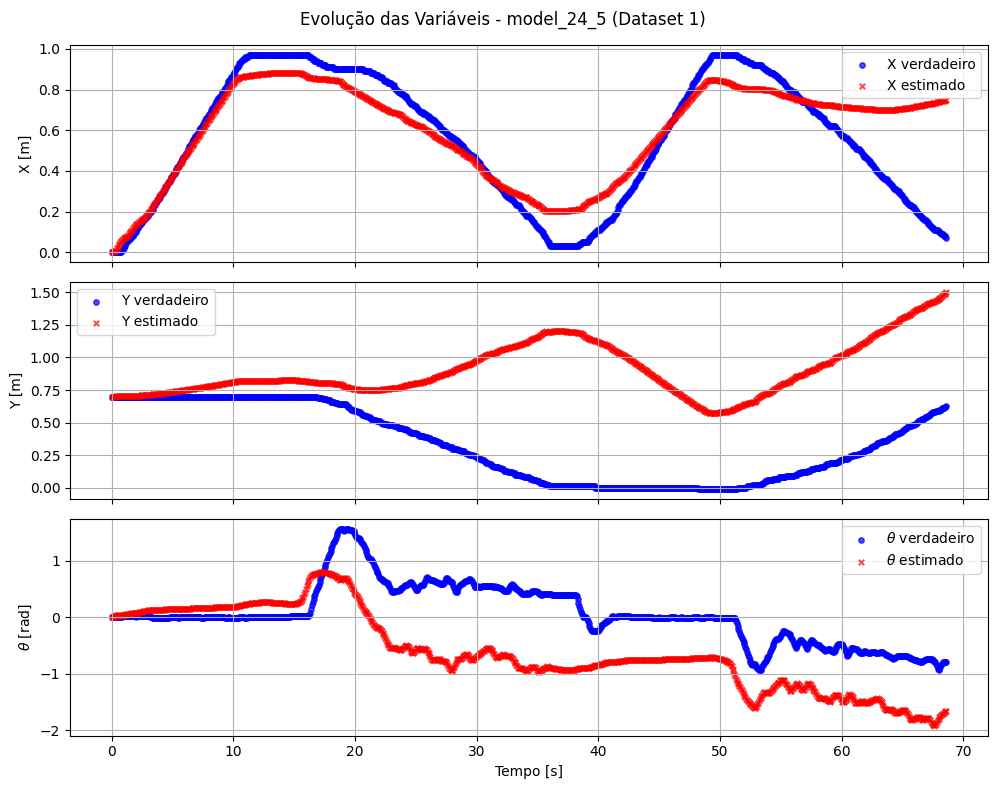

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

===== model_12_4 =====
R2_X = -4.3968, MSE_X = 0.545762
R2_Y = -13.0806, MSE_Y = 1.121632
R2_Theta = -242.1365, MSE_Theta = 68.300418


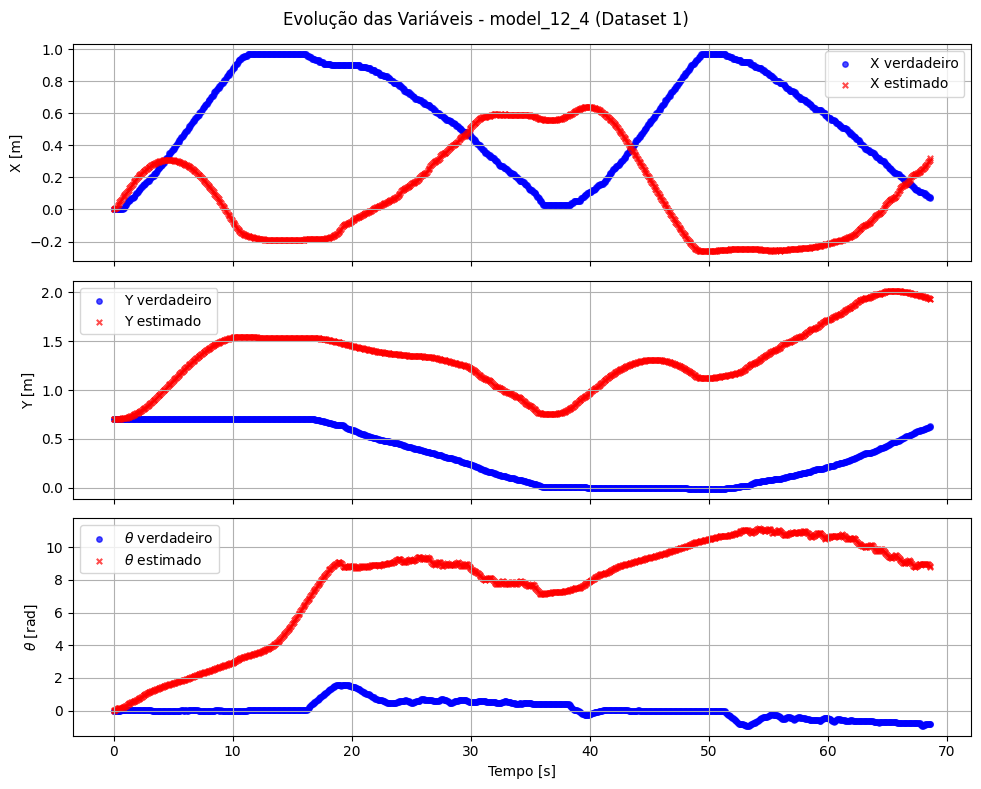

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

===== model_22_0 =====
R2_X = -0.3999, MSE_X = 0.141566
R2_Y = -2.6005, MSE_Y = 0.286807
R2_Theta = -1615.2879, MSE_Theta = 454.037702


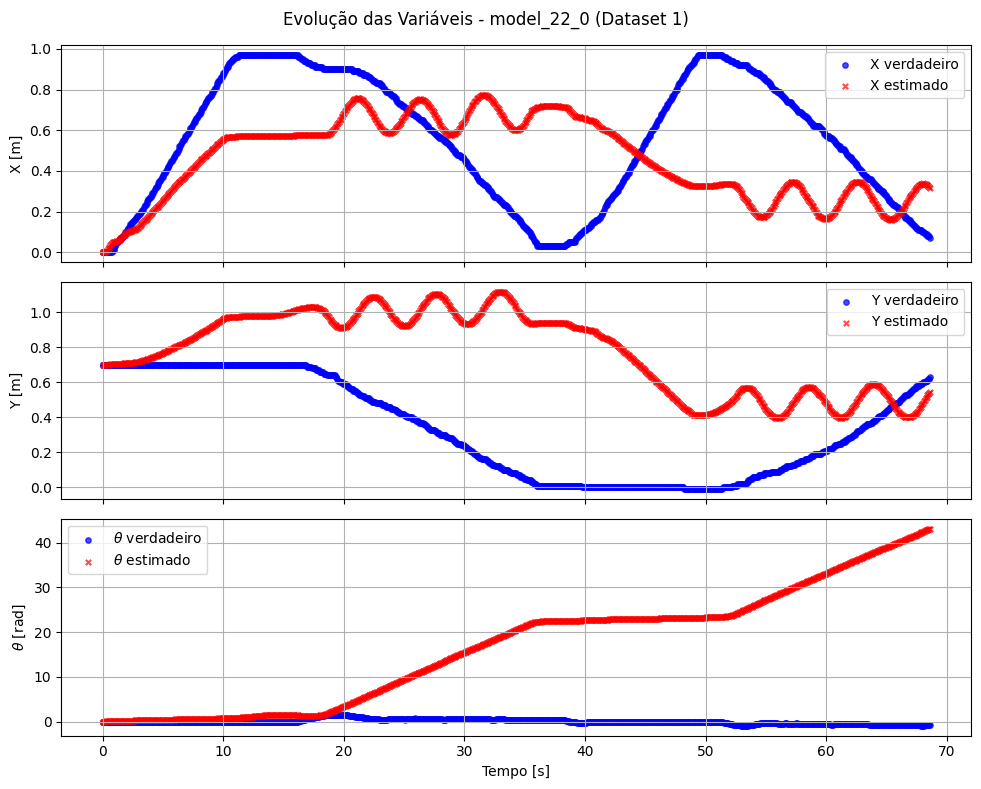

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

===== model_25_3 =====
R2_X = -0.5136, MSE_X = 0.153061
R2_Y = -10.3295, MSE_Y = 0.902488
R2_Theta = -8.6169, MSE_Theta = 2.701524


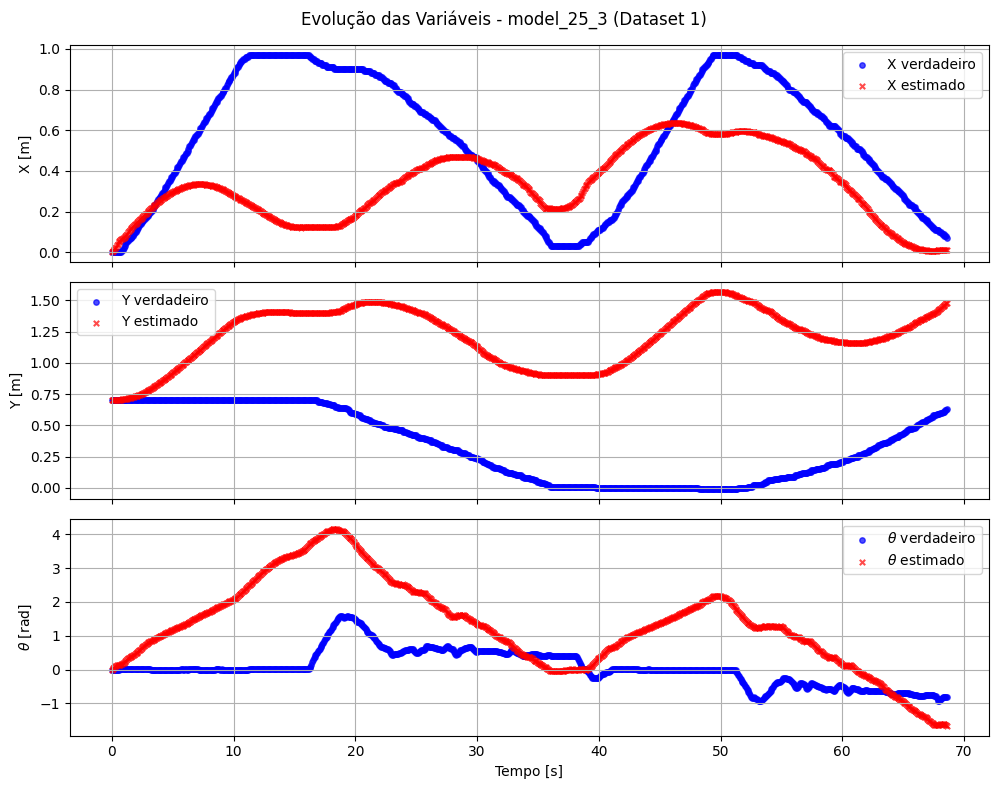



===== Avaliando Dataset 2 =====
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

===== model_24_5 =====
R2_X = -20.6477, MSE_X = 2.010776
R2_Y = -11.1850, MSE_Y = 0.636854
R2_Theta = -0.9763, MSE_Theta = 5.824293


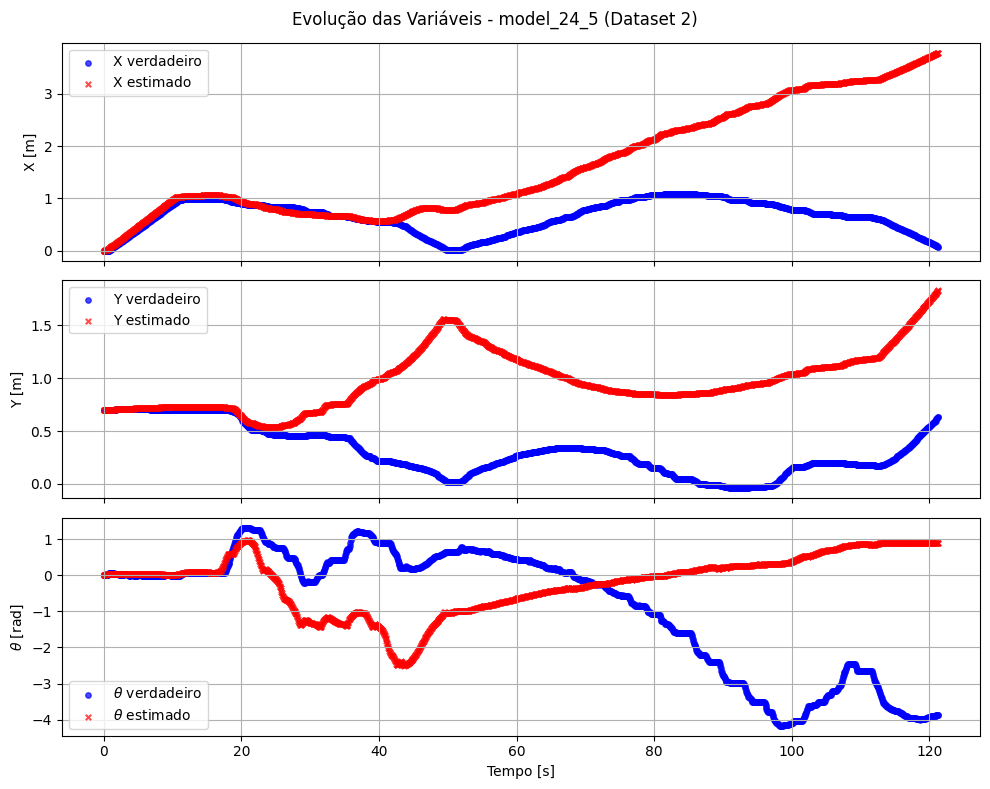

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

===== model_12_4 =====
R2_X = -2.8852, MSE_X = 0.360878
R2_Y = -11.2113, MSE_Y = 0.638228
R2_Theta = -80.5750, MSE_Theta = 240.404202


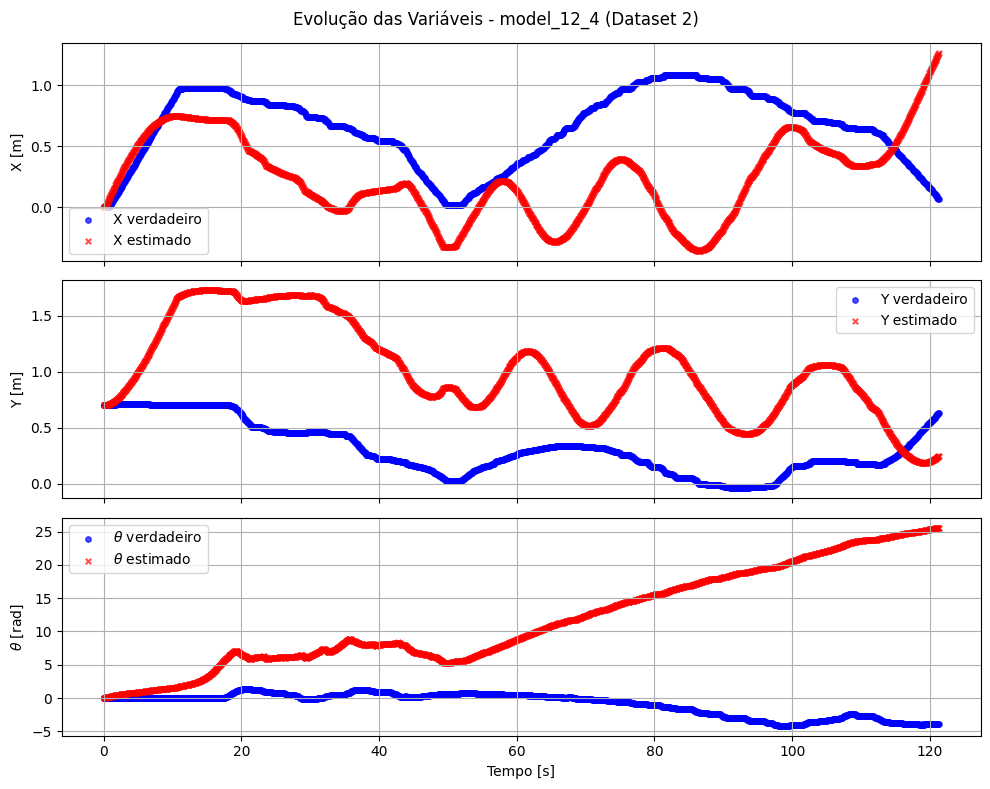

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_22_0 =====
R2_X = -3.7255, MSE_X = 0.438932
R2_Y = -27.3022, MSE_Y = 1.479221
R2_Theta = -268.7711, MSE_Theta = 795.023958


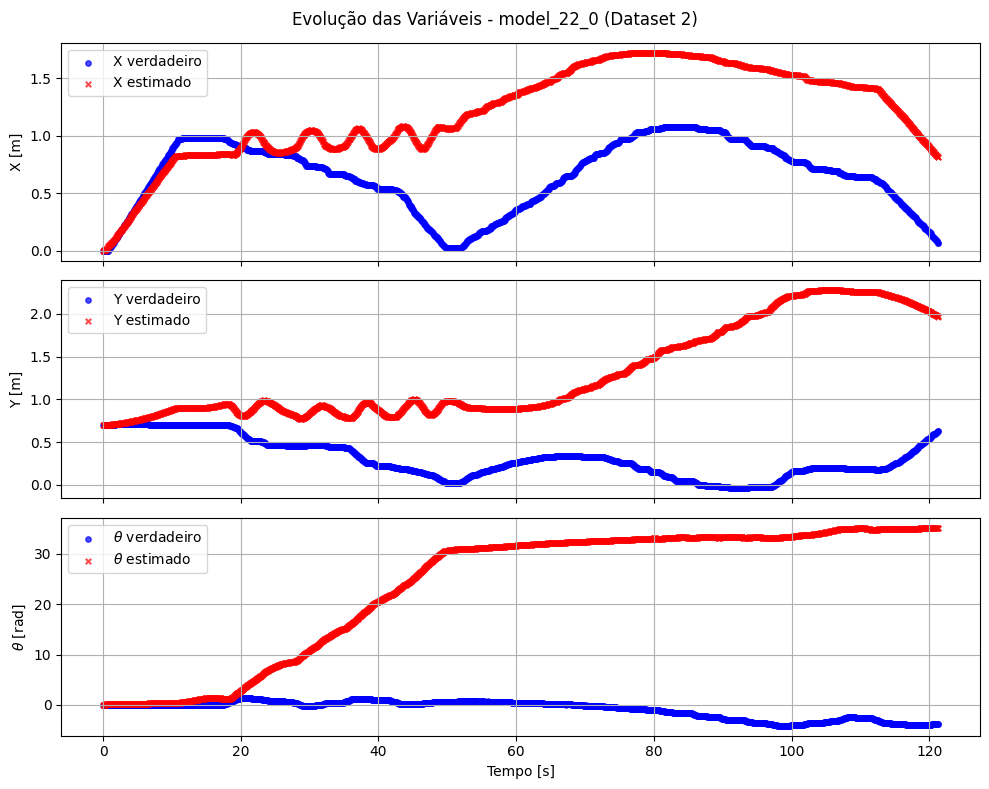

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_25_3 =====
R2_X = -1.7094, MSE_X = 0.251670
R2_Y = -21.5856, MSE_Y = 1.180445
R2_Theta = -14.8600, MSE_Theta = 46.739846


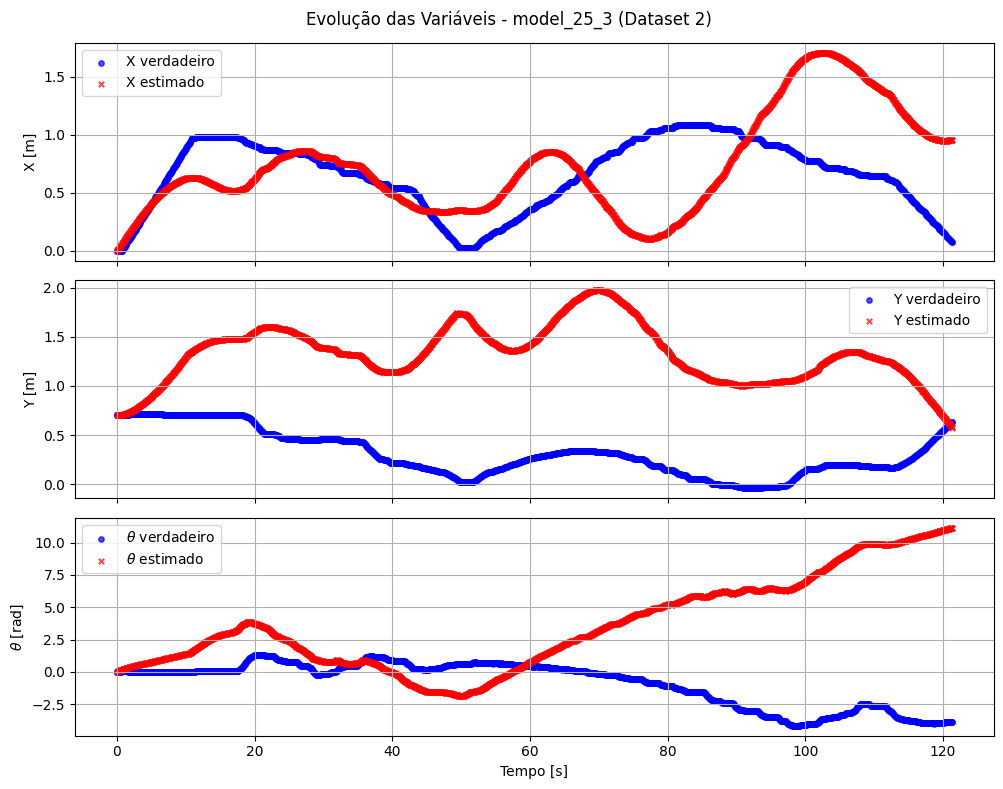



===== Avaliando Dataset 3 =====
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_24_5 =====
R2_X = 0.0718, MSE_X = 0.073396
R2_Y = -0.6743, MSE_Y = 0.099237
R2_Theta = -32.7487, MSE_Theta = 13.426560


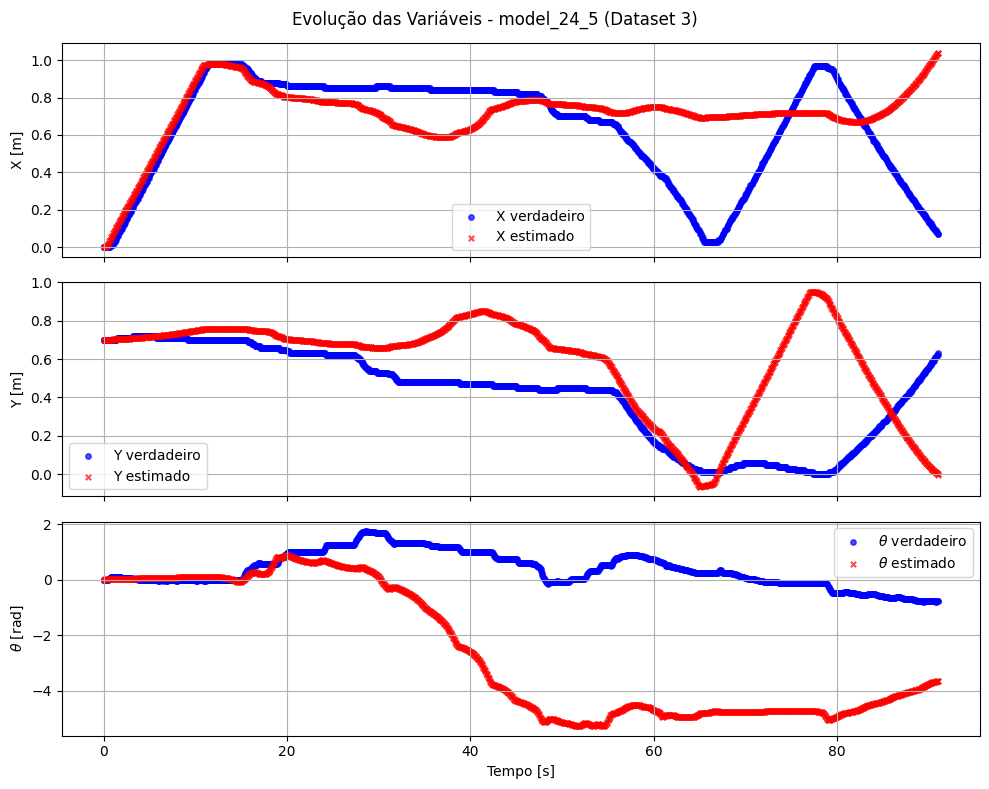

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

===== model_12_4 =====
R2_X = -2.3945, MSE_X = 0.268411
R2_Y = -37.9615, MSE_Y = 2.309304
R2_Theta = -262.9995, MSE_Theta = 105.029498


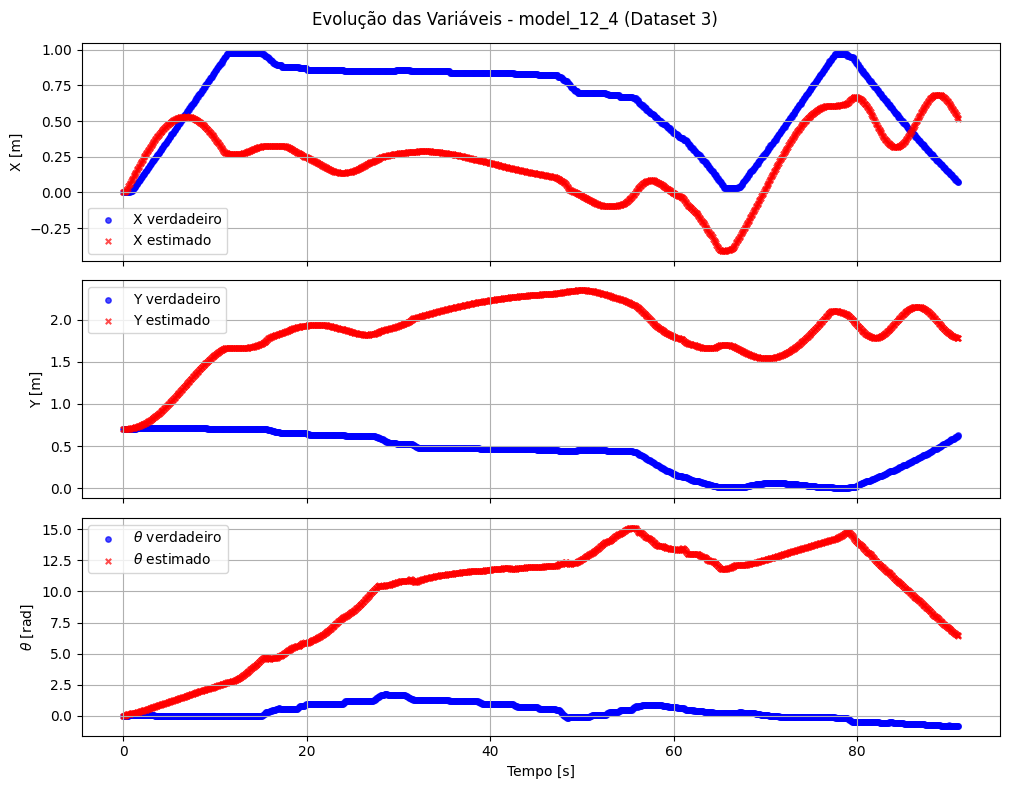

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_22_0 =====
R2_X = -0.8363, MSE_X = 0.145204
R2_Y = -1.8940, MSE_Y = 0.171529
R2_Theta = -2836.1277, MSE_Theta = 1128.722299


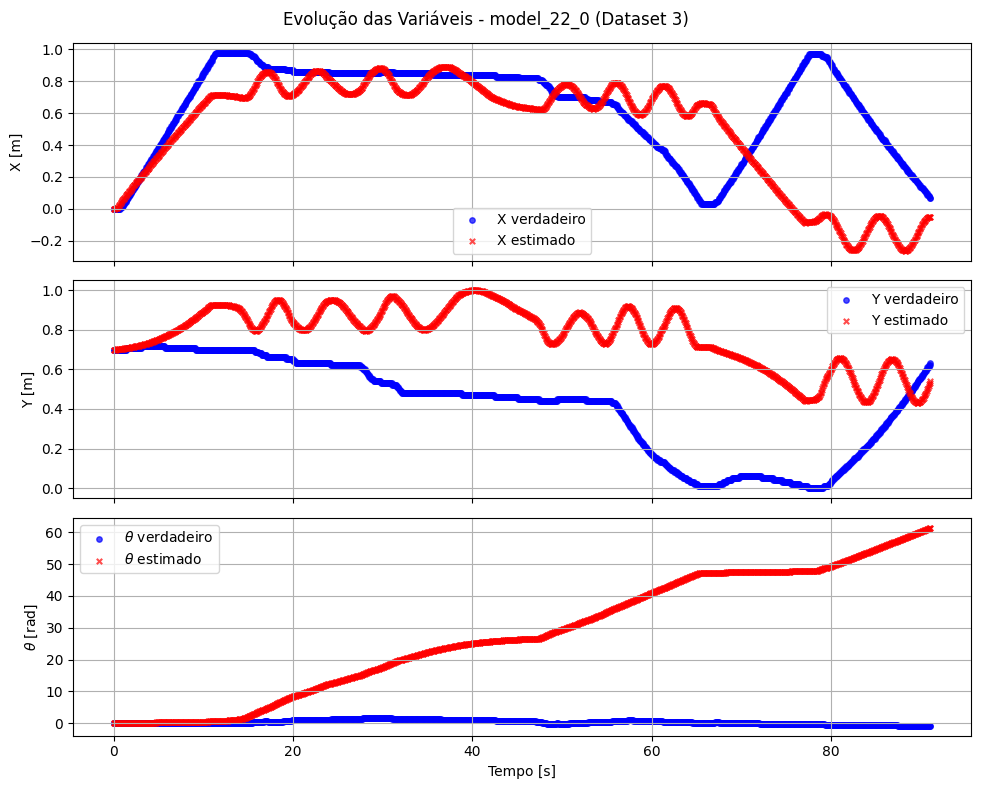

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_25_3 =====
R2_X = -1.9158, MSE_X = 0.230556
R2_Y = -7.0657, MSE_Y = 0.478065
R2_Theta = -27.1538, MSE_Theta = 11.200698


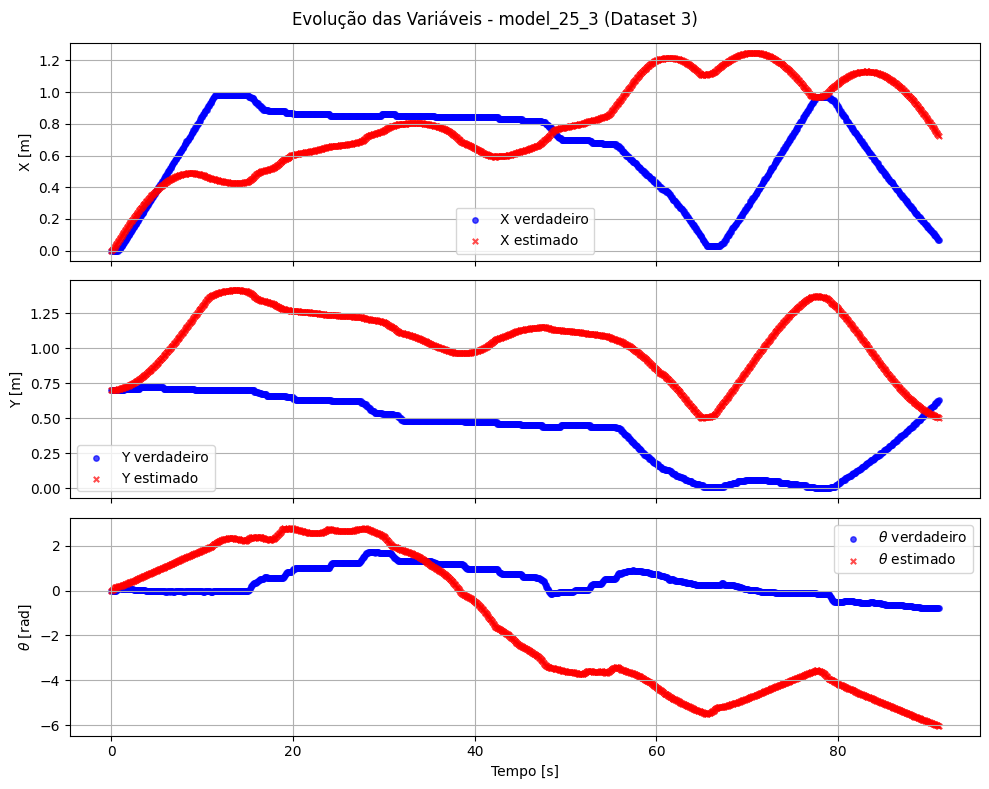



===== Avaliando Dataset 4 =====
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

===== model_24_5 =====
R2_X = 0.3594, MSE_X = 0.059185
R2_Y = -0.0101, MSE_Y = 0.074771
R2_Theta = -4.6110, MSE_Theta = 1.851363


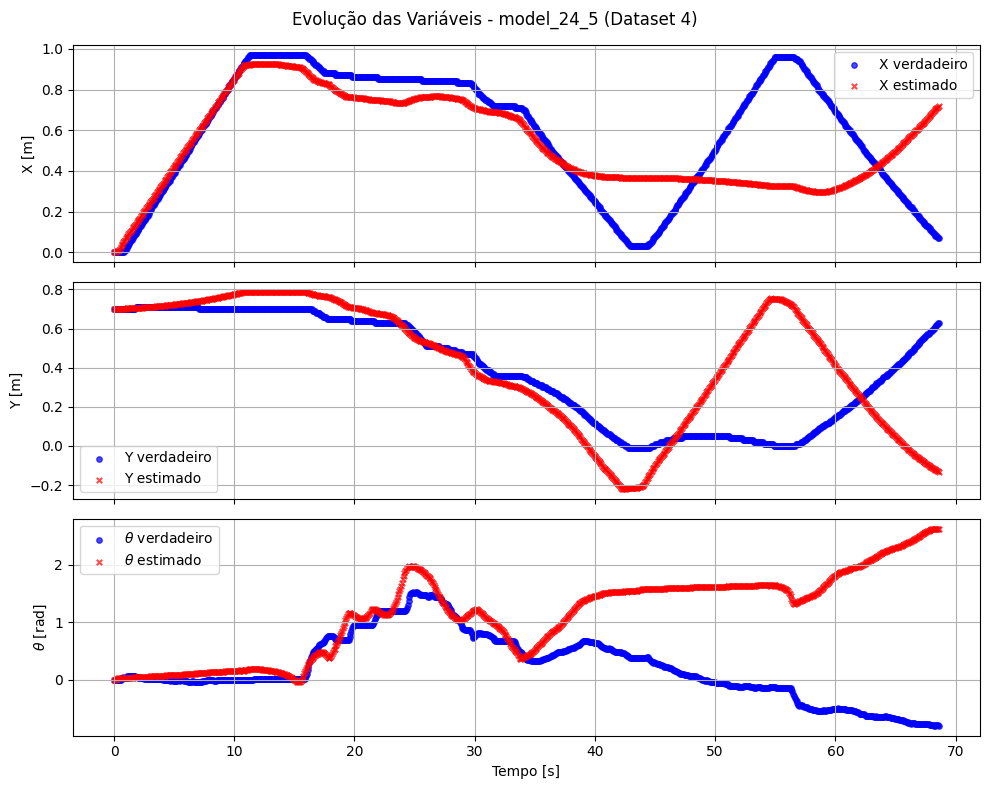

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

===== model_12_4 =====
R2_X = -2.9134, MSE_X = 0.361535
R2_Y = -6.9758, MSE_Y = 0.590376
R2_Theta = -111.5617, MSE_Theta = 37.140285


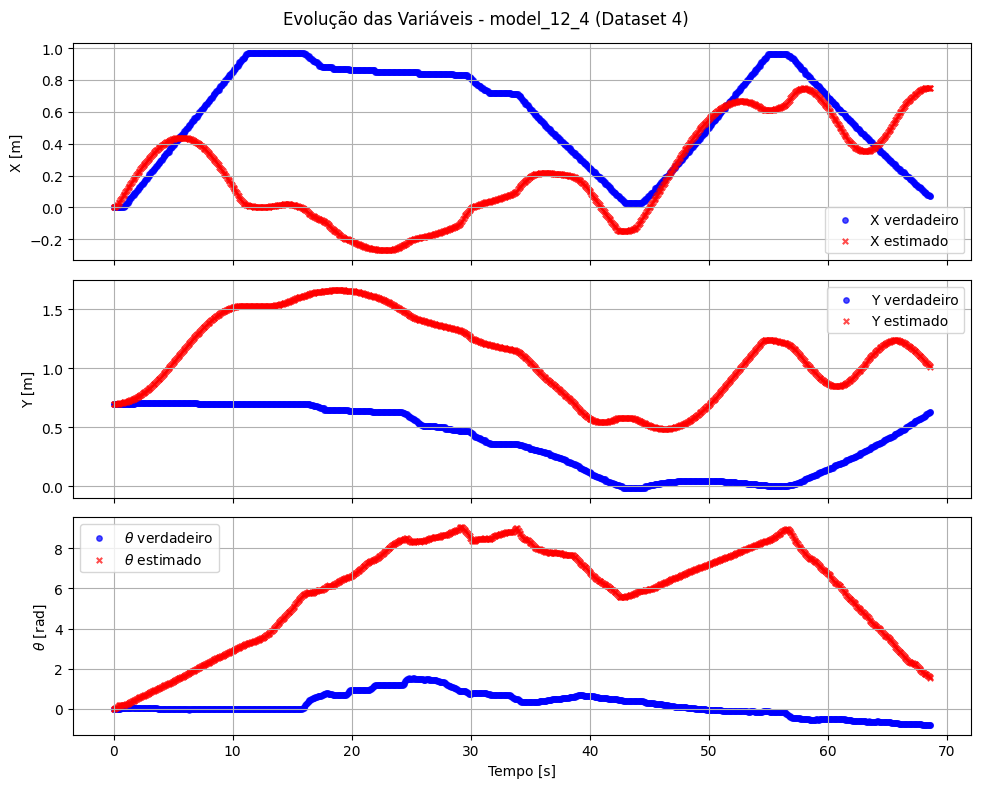

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_22_0 =====
R2_X = -1.1454, MSE_X = 0.198200
R2_Y = -3.0219, MSE_Y = 0.297707
R2_Theta = -2218.7369, MSE_Theta = 732.413157


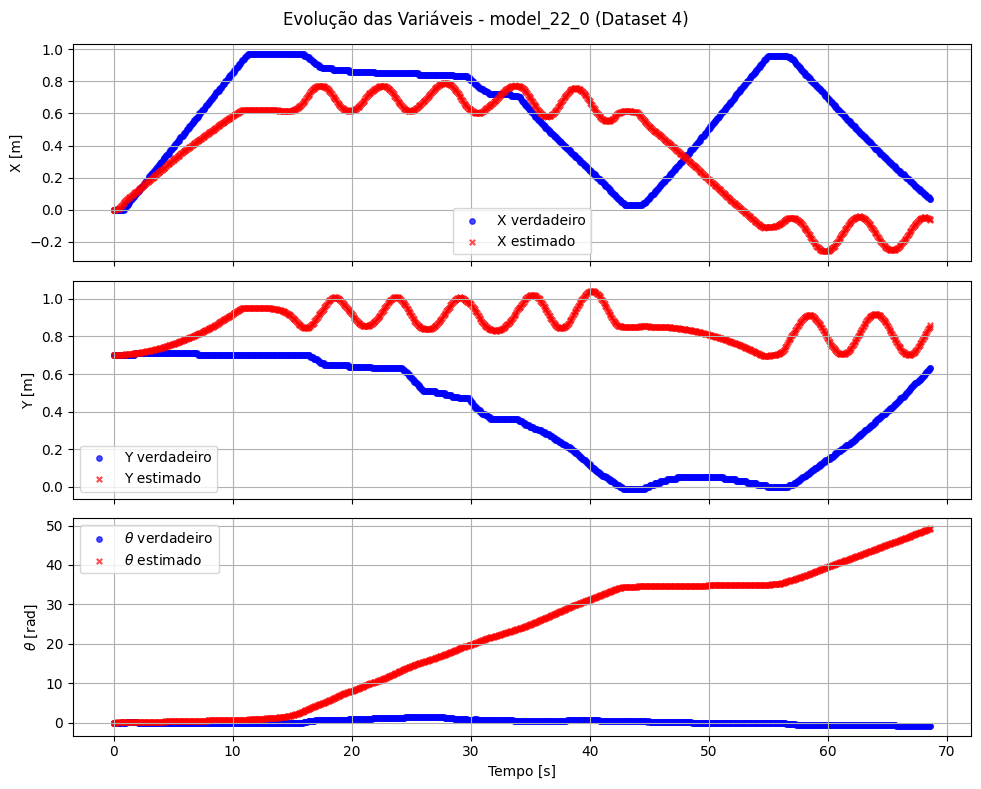

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

===== model_25_3 =====
R2_X = -1.1400, MSE_X = 0.197699
R2_Y = -9.1823, MSE_Y = 0.753707
R2_Theta = -10.2020, MSE_Theta = 3.696146


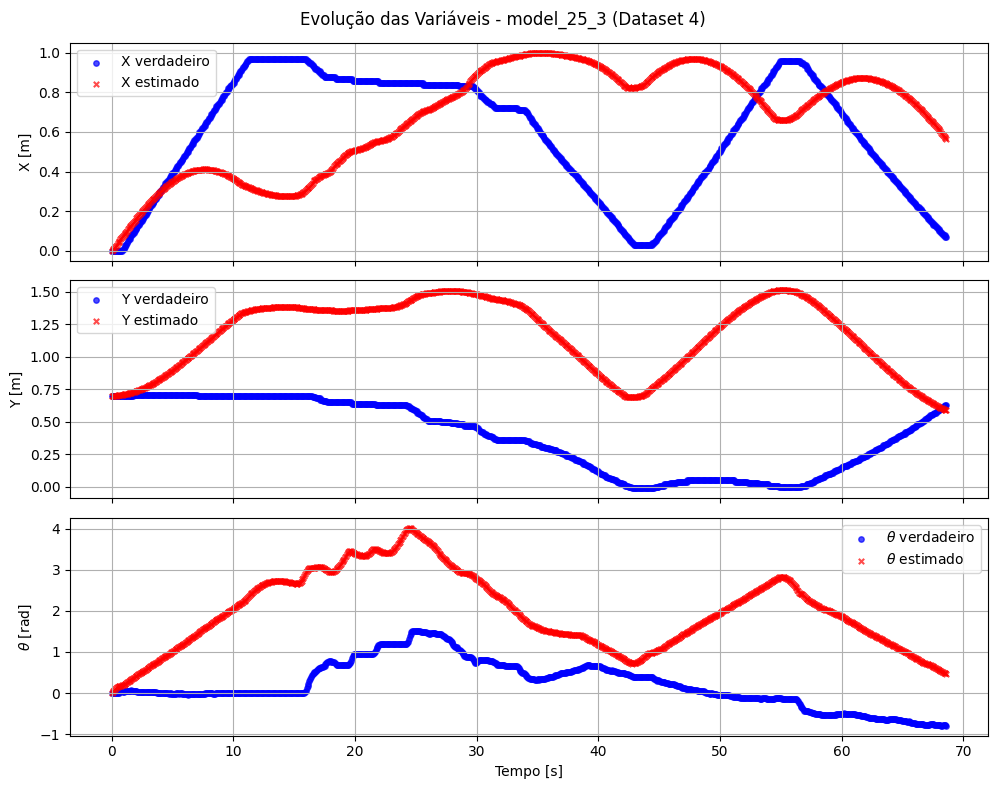

In [9]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

# -------------------------
# RECONSTRUÇÃO E AVALIAÇÃO
# -------------------------

results = []  # lista para armazenar métricas

# Correção: iteração simultânea deve usar zip()
for i, (NormDataset, Dataset) in enumerate(zip(NormDatasets, Datasets)):
    x_test, y_test = CreateSequences(NormDataset[PREDICTORS], NormDataset[TARGET], TIME_STEPS)
    Wd_We_true = OUT_SCALER.inverse_transform(y_test)

    X_true = Dataset["X"].values
    Y_true = Dataset["Y"].values
    Theta_true = Dataset["Theta"].values

    print(f"\n\n===== Avaliando Dataset {i+1} =====")

    for idx, ModelConf in ModelsConfs.iterrows():
        n = int(ModelConf["Neurons"])
        Name = ModelConf["model"]

        # --- Carrega pesos do modelo ---
        Wf = [np.array(w) for w in ast.literal_eval(ModelConf["Wf"])]

        model = keras.models.Sequential([
            keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)),
            keras.layers.SimpleRNN(n, activation="tanh"),
            keras.layers.Dense(OUTPUT_SIZE, activation="linear")
        ])
        model.set_weights(Wf)

        # --- Faz predição ---
        Wd_We_pred = OUT_SCALER.inverse_transform(model.predict(x_test))

        # --- Extrai velocidades previstas ---
        Wd_pred = Wd_We_pred[:, 0]   # ωd (roda direita)
        We_pred = Wd_We_pred[:, 1]   # ωe (roda esquerda)

        # --- Calcula odometria estimada ---
        X_est, Y_est, Theta_est = Odometry(Wd_pred, We_pred)

        # Garante que os tamanhos batem
        min_len = min(len(X_true), len(X_est))
        X_true, Y_true, Theta_true = X_true[:min_len], Y_true[:min_len], Theta_true[:min_len]
        X_est, Y_est, Theta_est = X_est[:min_len], Y_est[:min_len], Theta_est[:min_len]

        # --- Cálculo das métricas ---
        r2_x = r2_score(X_true, X_est)
        r2_y = r2_score(Y_true, Y_est)
        r2_theta = r2_score(Theta_true, Theta_est)

        mse_x = mean_squared_error(X_true, X_est)
        mse_y = mean_squared_error(Y_true, Y_est)
        mse_theta = mean_squared_error(Theta_true, Theta_est)

        print(f"\n===== {Name} =====")
        print(f"R2_X = {r2_x:.4f}, MSE_X = {mse_x:.6f}")
        print(f"R2_Y = {r2_y:.4f}, MSE_Y = {mse_y:.6f}")
        print(f"R2_Theta = {r2_theta:.4f}, MSE_Theta = {mse_theta:.6f}")

        # --- Armazena resultados ---
        results.append({
            "Dataset": i + 1,
            "Model": Name,
            "Neurons": n,
            "R2_X": r2_x, "MSE_X": mse_x,
            "R2_Y": r2_y, "MSE_Y": mse_y,
            "R2_Theta": r2_theta, "MSE_Theta": mse_theta
        })

        # --- Gera gráfico ---
        PlotTrajectoryEvolution(
            X_true, Y_true, Theta_true,
            X_est, Y_est, Theta_est,
            f"Evolução das Variáveis - {Name} (Dataset {i+1})"
        )
        
results_df = pd.DataFrame(results)
results_df.to_excel("Odometry.xlsx")


In [10]:
results_df.to_csv("odometry.csv")